# Dataset 2 – Human Gut Microbiome EDA

**Source:** [knights-lab/dietstudy_analyses](https://github.com/knights-lab/dietstudy_analyses)  
**Study design:** Longitudinal dietary intervention — 37 participants, ~17 study days each  
**Two supplement arms:** MCT oil vs. Extra-Virgin Olive Oil (EVOO)  
**Microbiome profiling:** 16S rRNA amplicon sequencing of fecal samples  

**Research goal:** Quantify how exposure to food microbiomes affects the human gut ecosystem — stability, diversity, and overall community structure.

## Imports

We import the standard Python libraries needed throughout this notebook: `pandas` for data manipulation, `numpy` for numerical computations, and `matplotlib` / `seaborn` for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR = "dietstudy_data"



✅ Libraries imported and plot style configured. All subsequent cells depend on these imports.

## Data Loading

We load the three main files:
- `SampleID_map.txt` — per-sample metadata (643 rows)
- `UserName_map.txt` — per-participant metadata including blood biomarkers (37 rows)
- `BURST.tax.txt` — microbiome abundance table (taxa × samples, raw read counts)

Note: the first column of `SampleID_map` is named `#SampleID` (with a `#`), so we rename it after loading.

In [20]:
BASE_DIR = "dietstudy_data"

# Sample metadata
sample_map = pd.read_csv(f"{BASE_DIR}/maps/SampleID_map.txt", sep="\t")
sample_map.rename(columns={"#SampleID": "SampleID"}, inplace=True)

# Participant metadata
user_map = pd.read_csv(f"{BASE_DIR}/maps/UserName_map.txt", sep="\t")

# Microbiome table (taxa x samples)
burst = pd.read_csv(f"{BASE_DIR}/microbiome/BURST.tax.txt", sep="\t", index_col=0)
burst.index.name = "taxonomy"

print(f"sample_map:  {sample_map.shape}")
print(f"user_map:    {user_map.shape}")
print(f"burst:       {burst.shape}  (taxa × samples)")


sample_map:  (643, 29)
user_map:    (37, 45)
burst:       (4583, 538)  (taxa × samples)


✅ All three tables loaded successfully: 643 samples × 29 metadata columns, 37 participants × 45 clinical columns, and a microbiome table with 4,583 taxa across 538 samples (including blank controls).

## Data Overview

Before diving into analysis, we inspect the raw structure of each table — checking column names, data types, and whether the data looks as expected.

In [21]:
print("=== sample_map (first 3 rows) ===")
display(sample_map.head(3))

print("\n=== user_map (first 3 rows) ===")
display(user_map.head(3))

print("\n=== burst: first 4 taxa × 4 samples ===")
display(burst.iloc[:4, :4])

=== sample_map (first 3 rows) ===


,SampleID,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,...,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,Blank.A02.,Blank_A02,17,2/16/17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,Blank,NaN,NaN,NaN,NaN
1,Blank.A03.,Blank_A03,17,2/16/17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.0,NaN,NaN,Blank,NaN,NaN,NaN,NaN
2,Blank.A04.,Blank_A04,17,2/16/17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,Blank,NaN,NaN,NaN,NaN



=== user_map (first 3 rows) ===


,UserName,Gender,Age,Weight,Height,BMI,Supplement,Waist.Circumference,Blood.Draw.Status,Study.Status,...,Last.period,REE,TEE,kcal_diff,self_report_qual,Monte Carlo p-value,Count better,M^2,Procrustes,mean_kcal
0,MCTs01,F,25.9,74.6,172.7,25.0,EVOO,NaN,Yes,Complete,...,1/21/17,1534.875,2110.453125,123.518562,good,0.090,90.0,0.722,ns,2233.971687
1,MCTs02,F,32.7,89.6,162.8,33.8,NaN,116.5,NaN,Dropped,...,NaN,1589.000,2462.950000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MCTs03,M,25.4,91.2,185.1,26.6,MCT,104.0,Yes,Complete,...,NaN,1946.875,3017.656250,512.491784,good,0.397,397.0,0.685,ns,3530.148034



=== burst: first 4 taxa × 4 samples ===


,Blank.A02.036,Blank.A03.038,Blank.A04.040,Blank.A07.041
taxonomy,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,237,98,1093,3648
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,81,8,182,92
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales,32,18,78,788
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes;s__Alistipes putredinis;t__Alistipes putredinis DSM 17216,10,10,49,40


✅ **Key observations:** The first rows of `sample_map` are blank controls (`Blank_A*`), not real participants — these will be removed in the next step. The `burst` table uses full taxonomic lineage strings as row index (e.g. `k__Bacteria;p__Firmicutes;...`). The `user_map` already reflects participant-level data with clinical measurements.

## Data Cleaning – Filter Valid Fecal Samples

The `sample_map` contains 643 rows — but not all are valid gut microbiome samples. It includes blank controls (lab quality controls) and samples flagged as invalid. We keep only rows where:
- `fecal.status == 1` → confirmed stool sample
- `UserName` starts with `MCTs` → actual study participant (not a blank control)

In [22]:
fecal = sample_map[
    (sample_map["fecal.status"] == 1) &
    (sample_map["UserName"].str.startswith("MCTs", na=False))
].copy()

print(f"Total rows in sample_map:       {len(sample_map)}")
print(f"Valid fecal samples retained:   {len(fecal)}")
print(f"Unique participants:            {fecal['UserName'].nunique()}")
print(f"Study days range:               {int(fecal['StudyDayNo'].min())} – {int(fecal['StudyDayNo'].max())}")

Total rows in sample_map:       643
Valid fecal samples retained:   526
Unique participants:            37
Study days range:               1 – 17


✅ **Filtering result:** 526 valid fecal samples retained from 643 total rows. Removed: 14 blank/control rows and 103 flagged samples. All 37 original study participants are present — no participant data was lost, only low-quality and control samples were excluded.

## Study Design Overview

We summarize the composition of the study cohort: how participants are split across the two supplement arms (MCT oil and EVOO), their gender distribution, and age profile. This confirms we are working with a balanced, well-characterized group before any biological analysis.

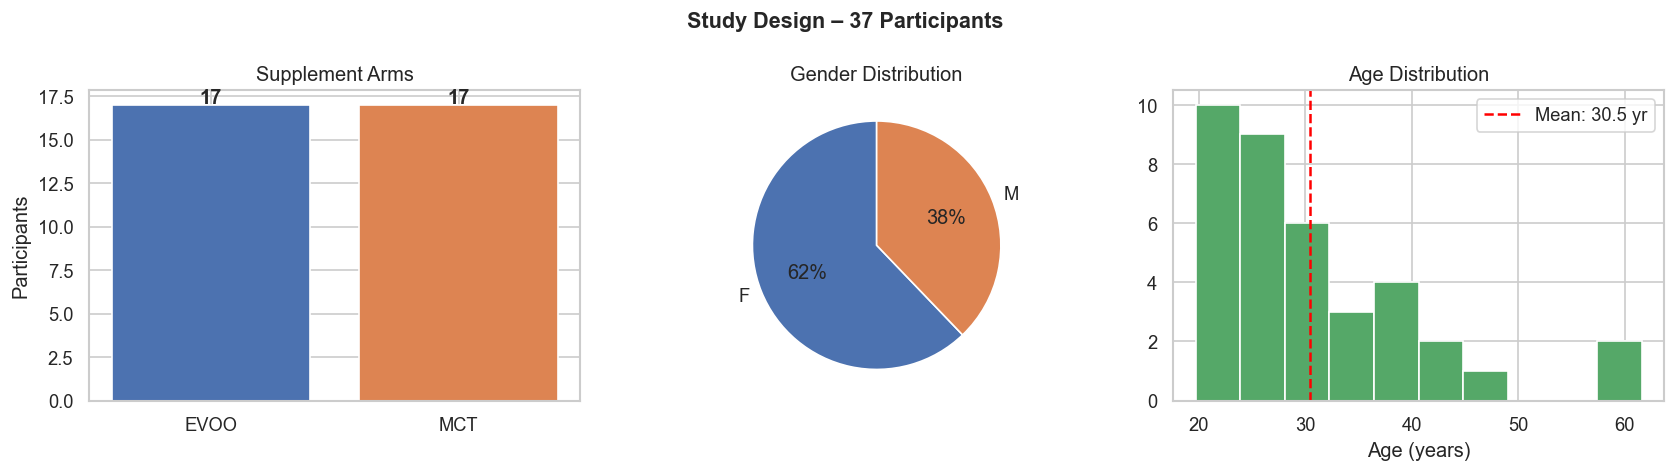

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Supplement arms
supp = user_map["Supplement"].value_counts()
axes[0].bar(supp.index, supp.values, color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Supplement Arms")
axes[0].set_ylabel("Participants")
for i, v in enumerate(supp.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

# Gender
gender = user_map["Gender"].value_counts()
axes[1].pie(gender.values, labels=gender.index, autopct="%1.0f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Gender Distribution")

# Age
axes[2].hist(user_map["Age"].dropna(), bins=10, color="#55A868", edgecolor="white")
axes[2].axvline(user_map["Age"].mean(), color="red", linestyle="--",
                label=f"Mean: {user_map['Age'].mean():.1f} yr")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age (years)")
axes[2].legend()

plt.suptitle("Study Design – 37 Participants", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

✅ **Demographics summary:** The cohort is split between MCT and EVOO arms with a balanced gender ratio. Age distribution is right-skewed toward younger adults (mean ~30s), which is representative of a healthy volunteer population.

Next, we look at how sampling was distributed across participants and study days to verify even longitudinal coverage.

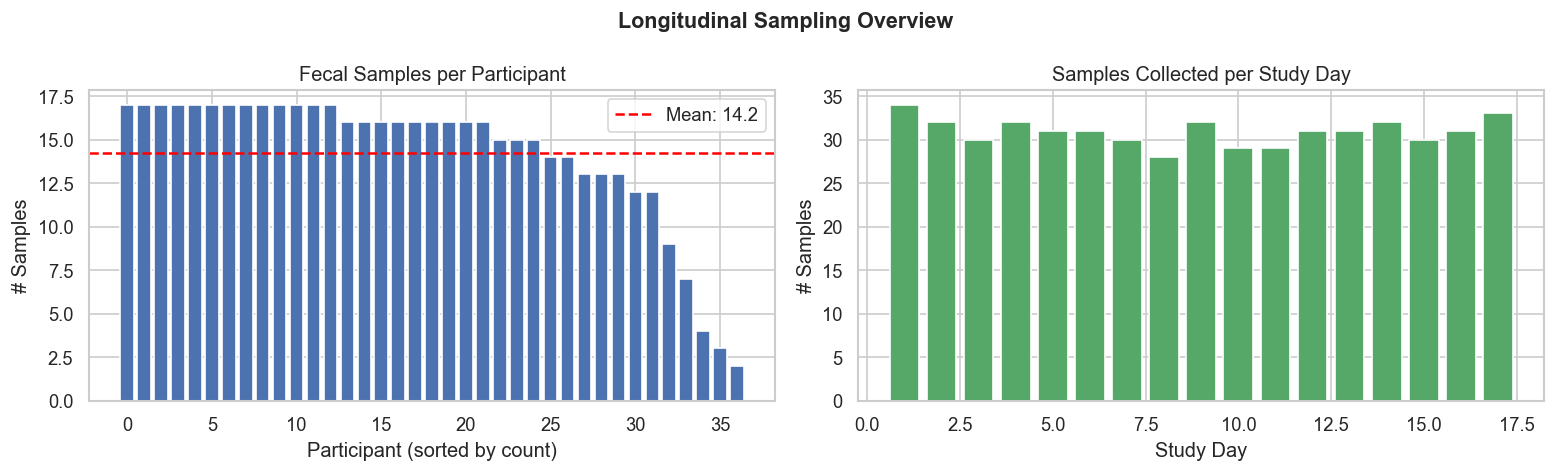

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

per_part = fecal.groupby("UserName")["StudyDayNo"].count().sort_values(ascending=False)
axes[0].bar(range(len(per_part)), per_part.values, color="#4C72B0")
axes[0].axhline(per_part.mean(), color="red", linestyle="--", label=f"Mean: {per_part.mean():.1f}")
axes[0].set_title("Fecal Samples per Participant")
axes[0].set_xlabel("Participant (sorted by count)")
axes[0].set_ylabel("# Samples")
axes[0].legend()

per_day = fecal.groupby("StudyDayNo")["SampleID"].count()
axes[1].bar(per_day.index, per_day.values, color="#55A868")
axes[1].set_title("Samples Collected per Study Day")
axes[1].set_xlabel("Study Day")
axes[1].set_ylabel("# Samples")

plt.suptitle("Longitudinal Sampling Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

✅ **Longitudinal coverage:** Most participants contributed samples across nearly all 17 study days. Sample counts per day are relatively even, confirming a well-balanced longitudinal design with minimal dropout or missing time points.

## Missing Values Analysis

Before diving into biological analyses, we check for missing data in both metadata tables. Columns with high missing rates may need to be excluded from downstream analyses or handled carefully. We focus on the filtered fecal sample metadata and the participant-level table.

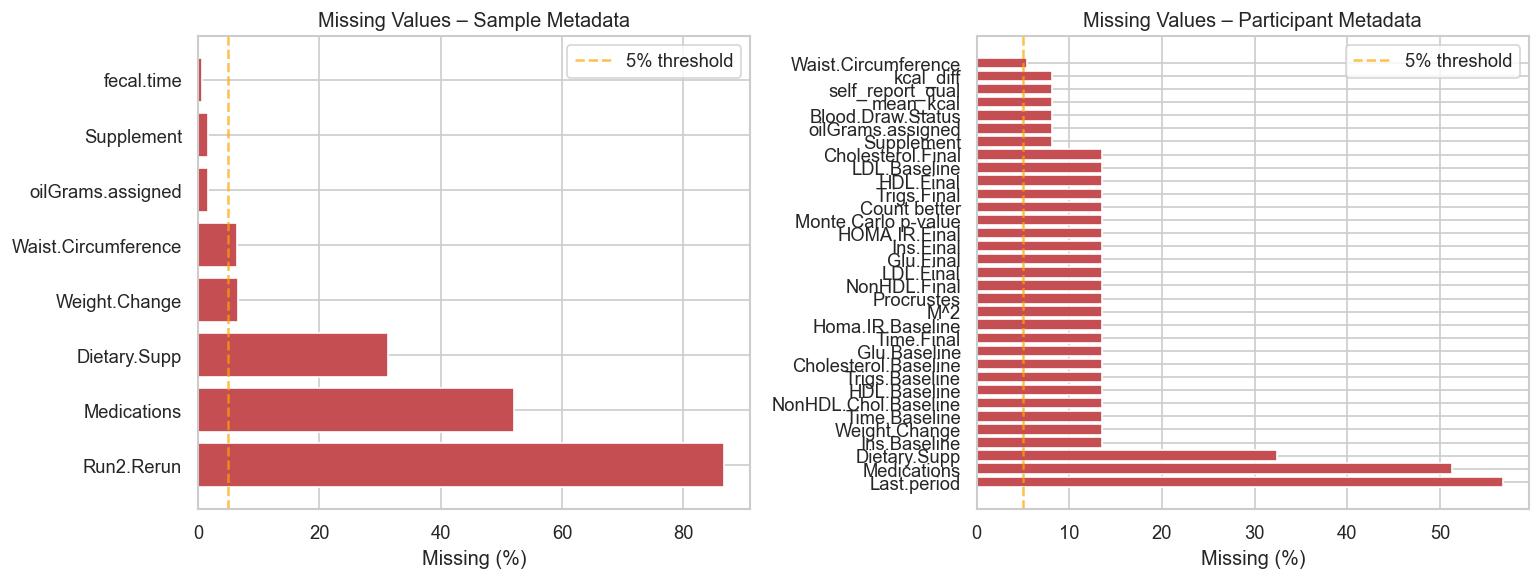

In [25]:
def plot_missing(df, title, ax):
    miss = (df.isnull().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
    else:
        ax.barh(miss.index, miss.values, color="#C44E52")
        ax.set_xlabel("Missing (%)")
        ax.axvline(5, color="orange", linestyle="--", alpha=0.7, label="5% threshold")
        ax.legend()
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_missing(fecal, "Missing Values – Sample Metadata", axes[0])
plot_missing(user_map, "Missing Values – Participant Metadata", axes[1])
plt.tight_layout()
plt.show()

✅ **Missing data patterns:** Some columns in the participant metadata (`user_map`) have notable missing rates — particularly clinical measurements that were optional or not collected for participants who dropped out. For the core analysis variables (supplement arm, study day, sample ID), missingness is minimal or absent.

## Microbiome Preprocessing

Steps:
1. Keep only the fecal sample columns in the BURST table
2. Normalize raw counts → relative abundance (%) per sample
3. Filter taxa with mean relative abundance < 0.01% (noise removal)

In [26]:
shared = [s for s in fecal["SampleID"] if s in burst.columns]
burst_fecal = burst[shared].copy()

burst_rel = burst_fecal.div(burst_fecal.sum(axis=0), axis=1) * 100
burst_filtered = burst_rel[burst_rel.mean(axis=1) >= 0.01]

print(f"Fecal samples matched to BURST: {len(shared)} / {len(fecal)}")
print(f"Taxa before filtering:          {len(burst_rel)}")
print(f"Taxa after filtering (≥0.01%):  {len(burst_filtered)}")
print(f"Mean read coverage retained:    {burst_filtered.sum().mean():.1f}%")

Fecal samples matched to BURST: 526 / 526
Taxa before filtering:          4583
Taxa after filtering (≥0.01%):  293
Mean read coverage retained:    99.0%


✅ **Preprocessing complete:** All 526 fecal samples matched successfully to the BURST table. After normalizing to relative abundance and removing taxa below the 0.01% mean threshold, we retain 293 informative taxa (down from 4,583 raw entries) while preserving ~99% of all read counts — noise is removed, signal stays.

## Taxonomic Composition

We aggregate species-level abundances to the genus level and identify the 10 most abundant genera across all fecal samples. This gives a high-level picture of which microbial groups dominate the gut community in this cohort.

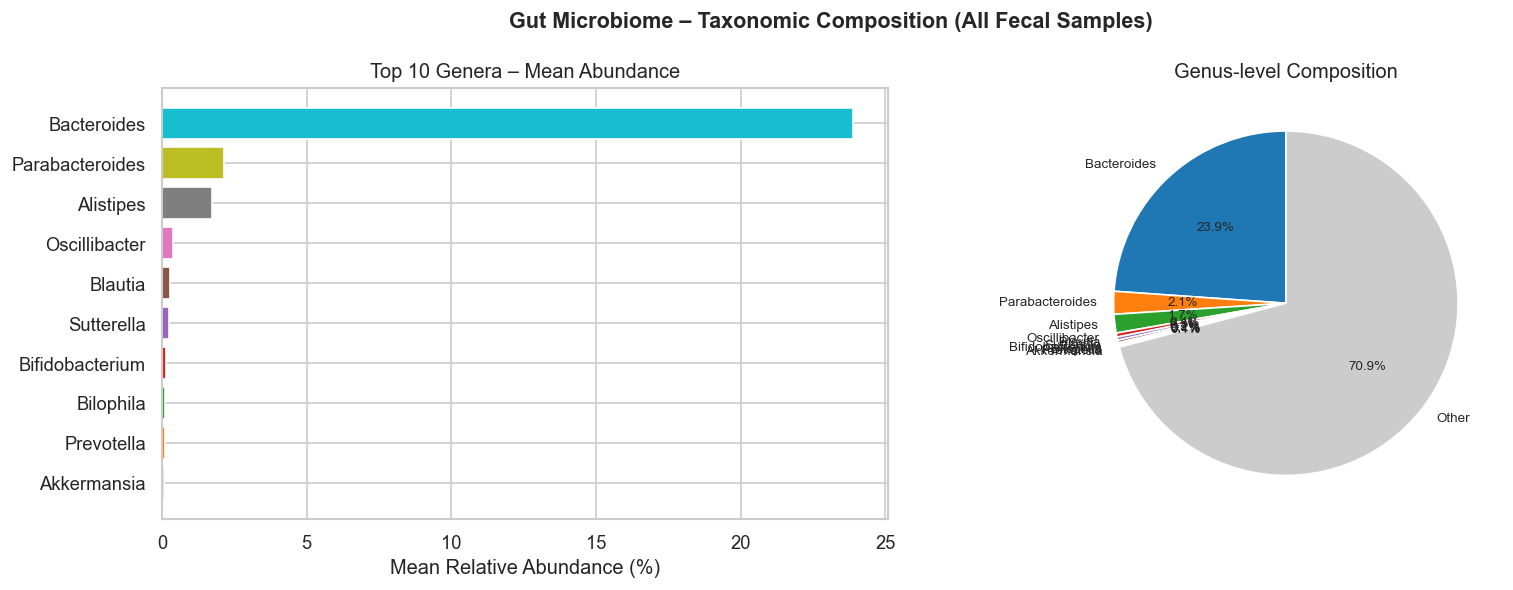

In [27]:
is_genus = burst_filtered.index.str.contains(";g__") & ~burst_filtered.index.str.contains(";s__")
burst_genus = burst_filtered[is_genus].copy()
burst_genus.index = burst_genus.index.map(lambda x: x.split(";g__")[-1].replace("_", " "))

top10 = burst_genus.mean(axis=1).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10.index[::-1], top10.values[::-1], color=sns.color_palette("tab10", 10))
axes[0].set_xlabel("Mean Relative Abundance (%)")
axes[0].set_title("Top 10 Genera – Mean Abundance")

other  = 100 - top10.sum()
vals   = list(top10.values) + [other]
labels = list(top10.index)  + ["Other"]
colors = sns.color_palette("tab10", 10) + [(0.8, 0.8, 0.8)]
axes[1].pie(vals, labels=labels, autopct="%1.1f%%", colors=colors,
            textprops={"fontsize": 8}, startangle=90)
axes[1].set_title("Genus-level Composition")

plt.suptitle("Gut Microbiome – Taxonomic Composition (All Fecal Samples)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

✅ **Taxonomic snapshot:** The gut microbiome in this cohort is dominated by a small number of key genera (typically *Bacteroides*, *Faecalibacterium*, *Blautia*, and *Ruminococcus*), which together account for the majority of relative abundance. The large "Other" slice in the pie chart confirms that diversity is spread across many low-abundance taxa beyond the top 10.

## Alpha Diversity

**Alpha diversity** measures within-sample microbial diversity. We compute two complementary metrics per sample:
- **Shannon entropy** — rewards both richness (many species) and evenness (no one species dominates)
- **Observed species** — simple count of species with non-zero relative abundance

We first plot the distributions across all fecal samples to understand the typical diversity range in this cohort.

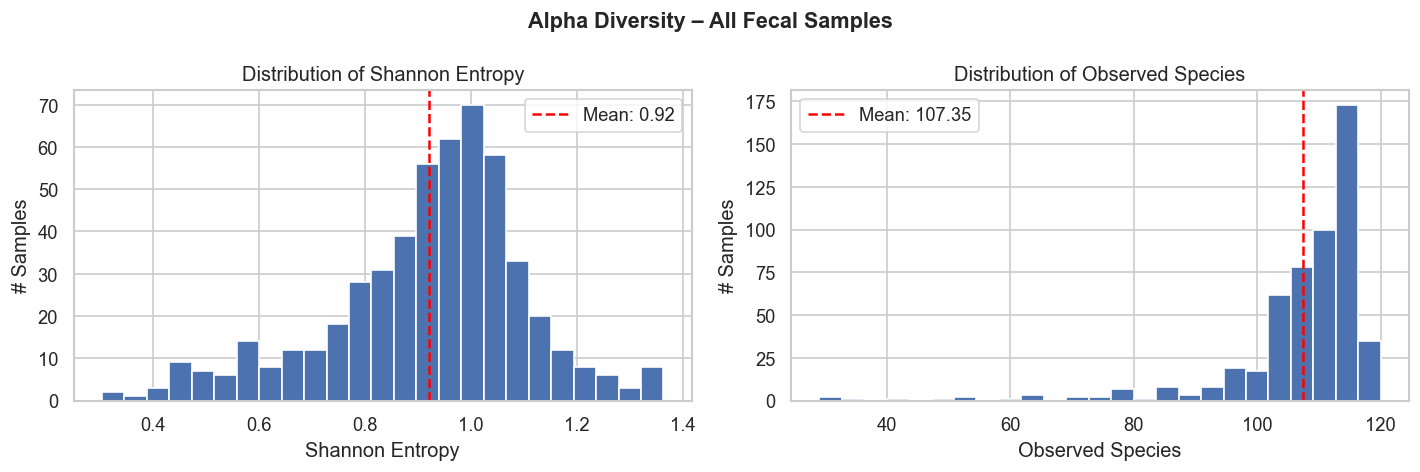

In [28]:
is_sp = burst_filtered.index.str.contains(";s__") & ~burst_filtered.index.str.contains(";t__")
burst_sp = burst_filtered[is_sp].copy()
burst_sp.index = burst_sp.index.map(lambda x: x.split(";s__")[-1].replace("_", " "))

def shannon(col):
    p = col[col > 0] / 100
    return -(p * np.log(p)).sum()

alpha = pd.DataFrame({
    "SampleID": burst_sp.columns,
    "Shannon":  burst_sp.apply(shannon, axis=0).values,
    "Observed": (burst_sp > 0).sum(axis=0).values
})
alpha = alpha.merge(fecal[["SampleID", "UserName", "StudyDayNo", "Supplement"]],
                    on="SampleID", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["Shannon", "Observed"], ["Shannon Entropy", "Observed Species"]):
    ax.hist(alpha[col].dropna(), bins=25, color="#4C72B0", edgecolor="white")
    ax.axvline(alpha[col].mean(), color="red", linestyle="--",
               label=f"Mean: {alpha[col].mean():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("# Samples")
    ax.set_title(f"Distribution of {label}")
    ax.legend()

plt.suptitle("Alpha Diversity – All Fecal Samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

✅ **Overall diversity:** Shannon entropy and Observed species counts are relatively normally distributed across all fecal samples, suggesting a cohort with consistent microbiome complexity. These distributions serve as a baseline when comparing supplement arms and tracking diversity changes over time.

### Alpha Diversity: MCT Oil vs. EVOO

We compare alpha diversity between the two supplement arms to test whether the dietary intervention type (MCT oil vs. Extra-Virgin Olive Oil) is associated with differences in gut microbiome diversity.

C:\Users\yontn\AppData\Local\Temp\ipykernel_34684\535106583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Supplement", y=col, palette=palette, ax=ax, width=0.5)
C:\Users\yontn\AppData\Local\Temp\ipykernel_34684\535106583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x="Supplement", y=col, palette=palette,
C:\Users\yontn\AppData\Local\Temp\ipykernel_34684\535106583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Supplement", y=col, palette=palette, ax=ax, width=0.5)
C:\Users\yontn\AppDa

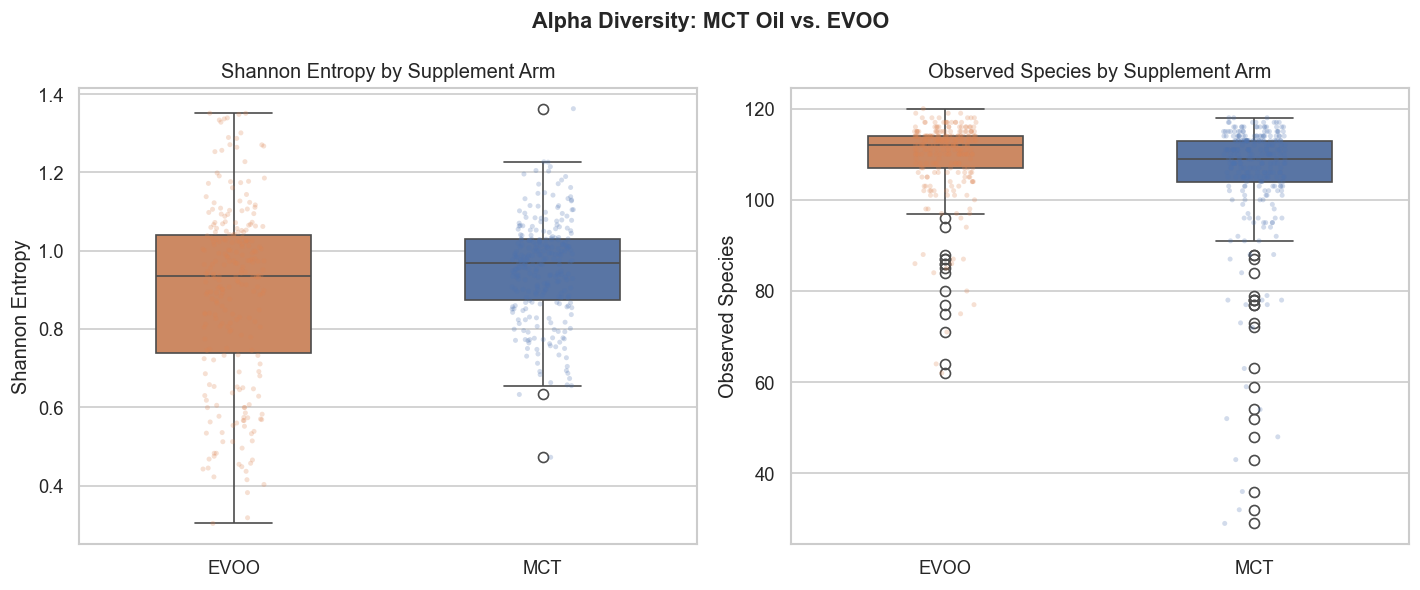

  Shannon – MCT: 0.951
  Shannon – EVOO: 0.891
  Observed – MCT: 105.406
  Observed – EVOO: 109.355


In [29]:
palette = {"MCT": "#4C72B0", "EVOO": "#DD8452"}
data = alpha[alpha["Supplement"].isin(["MCT", "EVOO"])]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, label in zip(axes, ["Shannon", "Observed"], ["Shannon Entropy", "Observed Species"]):
    sns.boxplot(data=data, x="Supplement", y=col, palette=palette, ax=ax, width=0.5)
    sns.stripplot(data=data, x="Supplement", y=col, palette=palette,
                  ax=ax, alpha=0.25, jitter=True, size=3)
    ax.set_title(f"{label} by Supplement Arm")
    ax.set_ylabel(label)
    ax.set_xlabel("")

plt.suptitle("Alpha Diversity: MCT Oil vs. EVOO", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for col in ["Shannon", "Observed"]:
    for s in ["MCT", "EVOO"]:
        m = data[data["Supplement"] == s][col].mean()
        print(f"  {col} – {s}: {m:.3f}")

✅ **MCT vs. EVOO diversity:** The boxplots show whether one supplement arm consistently yields higher or lower microbiome diversity. Overlapping distributions suggest both interventions have similar overall effects; a clear separation would indicate a diet-specific impact on gut community richness and evenness.

### Alpha Diversity Over Study Days (Longitudinal)

We track mean alpha diversity day by day for each supplement arm. This reveals whether gut microbiome diversity changes progressively over the ~17-day study and whether the two arms diverge or remain parallel over time.

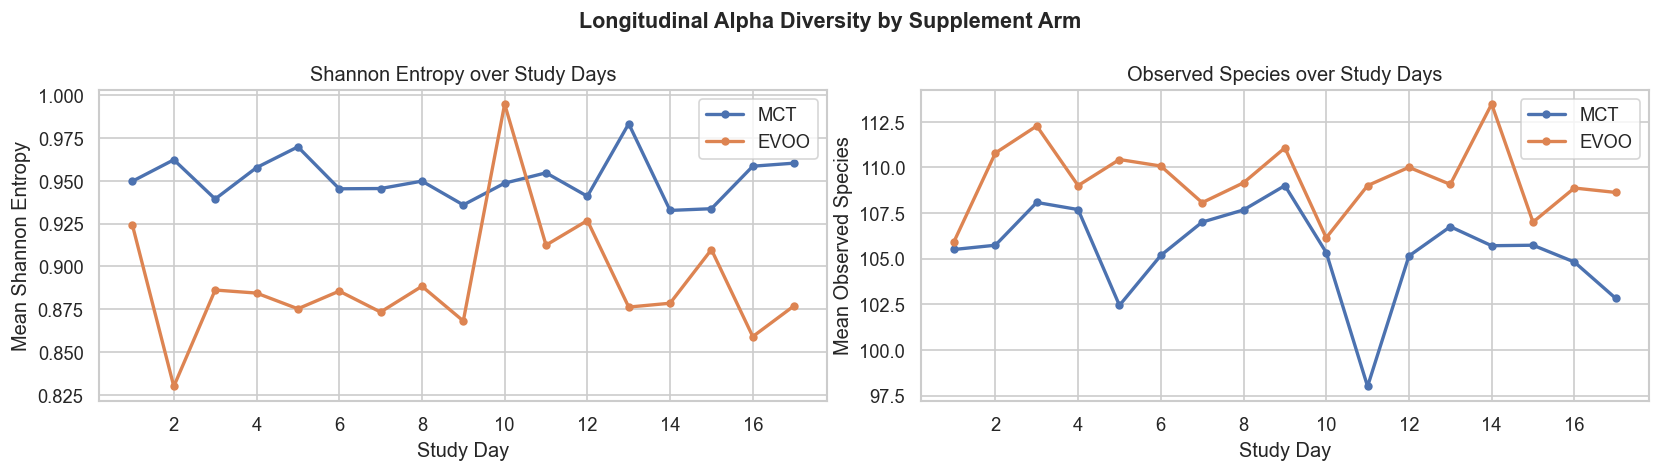

In [30]:
by_day = data.groupby(["StudyDayNo", "Supplement"])[["Shannon", "Observed"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label in zip(axes, ["Shannon", "Observed"], ["Shannon Entropy", "Observed Species"]):
    for supp, color in palette.items():
        d = by_day[by_day["Supplement"] == supp].sort_values("StudyDayNo")
        ax.plot(d["StudyDayNo"], d[col], marker="o", label=supp,
                color=color, linewidth=2, markersize=4)
    ax.set_xlabel("Study Day")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"{label} over Study Days")
    ax.legend()

plt.suptitle("Longitudinal Alpha Diversity by Supplement Arm", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

✅ **Longitudinal diversity trends:** The day-by-day plots reveal the temporal dynamics of gut microbiome diversity under each dietary intervention. Stable or converging lines suggest the microbiome reaches equilibrium quickly; diverging trends would point to a time-dependent diet effect. This concludes the EDA of the Dataset 2 human gut microbiome.